In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, csv
import os, sys
import neurokit2 as nk
# sys.path.append((os.path.abspath(os.path.join(os.getcwd(), '..'))))  # Add parent directory to sys.path
from datetime import datetime, timezone
from scipy.signal import resample, butter, filtfilt, find_peaks, hilbert, savgol_filter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('default')  # Use default style for better visibility of gridlines

In [59]:
def find_idx(target_time, timestamps, time_zone="UTC", exact=False):
    # Parse timestamps as timezone-aware UTC for reliable matching.
    ts = pd.to_datetime(timestamps, utc=True)
    
    # Interpret target_time in the provided timezone, then convert to UTC.
    target = pd.to_datetime(target_time)
    if target.tzinfo is None:
        target = target.tz_localize(time_zone)
    else:
        target = target.tz_convert(time_zone)
    target = target.tz_convert("UTC")
    
    if exact:
        matches = (ts == target)
        if matches.any():
            return matches.argmax()   # 第一个匹配位置
        else:
            raise ValueError(f"target_time {target} 不在 timestamps 中")
    else:
        # 找最近的时间点
        diff = abs(ts - target)
        return diff.argmin()
    

def norm_sig(ECG):
    ECG = (ECG - np.min(ECG)) / (np.max(ECG) - np.min(ECG))
    return ECG


In [ ]:
# Example of the data structure
def new_struct():
    data_struct = {
        "Info" : {
            "Subject" : None, 
            "Bed_angle" : None, # 0°, 15°,  20°, 30°
            "Posture" : None, # Back
            "Test" : None, # Post exercise or Cold pressor test (CP)
            "Other_comment" : None,
        },
        # can add bed if needed
        "Bed_ID" : 'AF', # can be: AF or 15
        "BD_up" : None, # BedDot upper sensor, [BSG_x, BSG_y, BSG_z]
        "SCG_z" : None,
        "ECG" : None,
        "Timestamp" : None,

        # The following items are only used for AF Bed with 3 sets of BedDot
        "BD_compare" : None, # BedDot compare sensor, [BSG_x, BSG_y, BSG_z]
        "BD_mid" : None, # BedDot middle sensor, [BSG_x, BSG_y, BSG_z]
        # The data from on-bed BedDot, only available for some trials.
        "BD_on" : None, # BedDot on the bed, [BSG_z]
    }
    return data_struct

root_path = './data_final/'
fs = 100


In [61]:
file_name = './HR_BP_varying/bed_AF_sub_1_legup_1_.npy'
data = np.load(file_name, allow_pickle=True).item()
print(data.keys())
print(data['Other_comment'])

dict_keys(['Info', 'Bed_ID', 'BD_up', 'SCG_z', 'ECG', 'ABP', 'Timestamp', 'BD_compare', 'BD_mid', 'BD_on', 'Other_comment'])
Leg up before idx 26800, with SBP/DBP = 130/83, then rest with SBP/DBP = 125/77.


In [ ]:
signal_up = data['BD_up'][2] # x,y,z axis 
signal_cp, signal_mid = data['BD_compare'][2], data['BD_mid'][2]
scg_z = data['SCG_z']

Start time: 2026-03-17 06:36:28 End time: 2026-03-17 06:42:28


Start index: 6000 End index: 7000


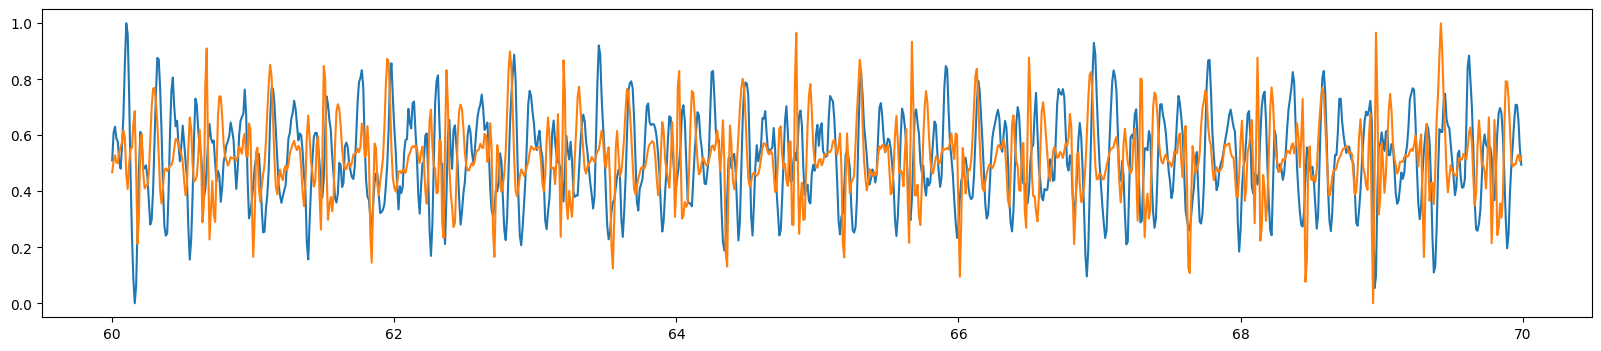

In [82]:
start_idx = 6000
end_idx = start_idx + 1000
print("Start index:", start_idx, "End index:", end_idx)
t = np.arange(len(signal_up)) / fs
plt.figure(figsize=(20, 4))
plt.plot(t[start_idx:end_idx], norm_sig(signal_up[start_idx:end_idx]), label='BD_up')
plt.plot(t[start_idx:end_idx], norm_sig(scg_z[start_idx:end_idx]), label='SCG_z')